# Segmentation client
 Objectif :
    *connaître clientèle cible 
    *marketing ciblé  
    *comprendre comportement 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("../data/marketing_campaign_cleaned.csv")
df = data.copy()

features = ['Income', 'Recency', 'Education_encoded',
       'Marital_Status_encoded', 'Age', 'Seniority', 'TotalMnt',
       'TotalPurchases', 'TotalChildren']
X_scaled = df[features]
print("Shape:", X_scaled.shape)
print(X_scaled.describe())

Shape: (2213, 9)
             Income       Recency  Education_encoded  Marital_Status_encoded  \
count  2.213000e+03  2.213000e+03       2.213000e+03            2.213000e+03   
mean  -1.380630e-16  1.083634e-16      -1.814083e-16           -1.581303e-16   
std    1.000226e+00  1.000226e+00       1.000226e+00            1.000226e+00   
min   -2.006831e+00 -1.693930e+00      -2.447767e+00           -2.365819e+00   
25%   -6.726694e-01 -8.648923e-01      -4.569885e-01           -4.605943e-01   
50%   -3.450254e-02 -1.311176e-03      -4.569885e-01            4.920180e-01   
75%    6.500931e-01  8.622700e-01       5.384008e-01            4.920180e-01   
max    2.440219e+01  1.725851e+00       1.533790e+00            2.397242e+00   

                Age     Seniority      TotalMnt  TotalPurchases  TotalChildren  
count  2.213000e+03  2.213000e+03  2.213000e+03    2.213000e+03   2.213000e+03  
mean  -2.929825e-17  8.283779e-16  4.173997e-17    9.190821e-17   2.247537e-17  
std    1.000226e+00

## Étape 1 :verifier la correlation entre les differents features

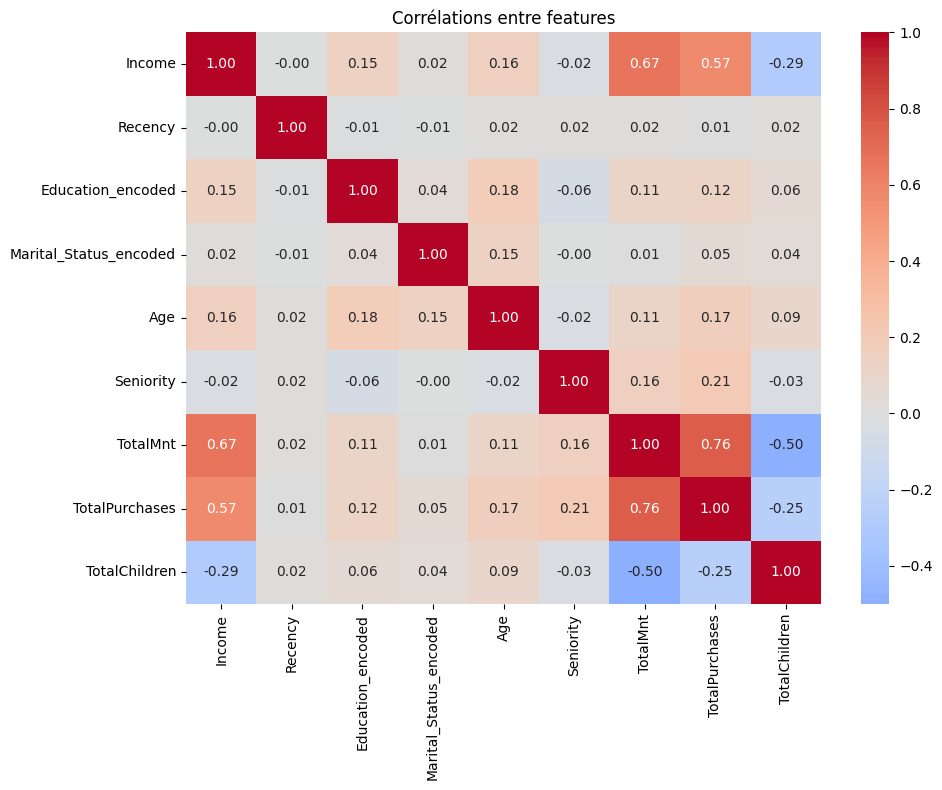

In [11]:
# Matrice de corrélation pour comprendre les features
plt.figure(figsize=(10, 8))
corr = X_scaled.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Corrélations entre features')
plt.tight_layout()
plt.show()

## Étape 2 : Tester différents k avec le score silhouette 

Meilleur k selon Silhouette : 2 (score = 0.2156)


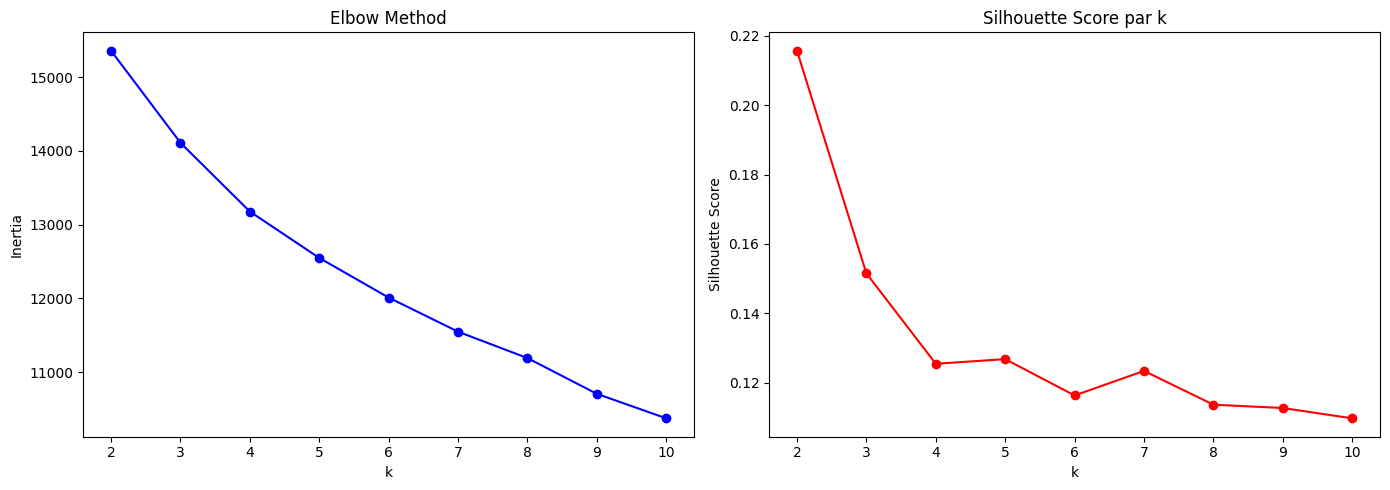

In [12]:
# Comparer Elbow + Silhouette score pour chaque k
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score par k')

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Meilleur k selon Silhouette : {best_k} (score = {max(silhouette_scores):.4f})")

plt.tight_layout()
plt.show()

## Étape 3 : Sélection des meilleures features 

Avec features optimisées — Meilleur k : 2 (score = 0.3697)


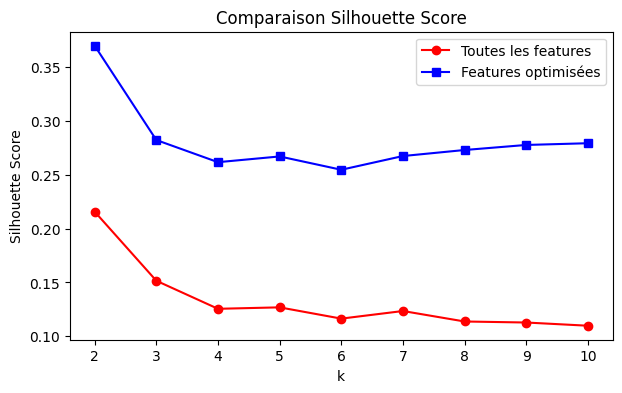

In [13]:
# On retire Education_encoded et Marital_Status_encoded qui sont catégorielles
features_optimisees = ['Income', 'Recency', 'TotalMnt', 'TotalPurchases', 'TotalChildren']

X_opt = df[features_optimisees]

# Tester différents k
silhouette_opt = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_opt)
    silhouette_opt.append(silhouette_score(X_opt, labels))

best_k_opt = K_range[silhouette_opt.index(max(silhouette_opt))]
print(f"Avec features optimisées — Meilleur k : {best_k_opt} (score = {max(silhouette_opt):.4f})")

plt.figure(figsize=(7, 4))
plt.plot(K_range, silhouette_scores, 'ro-', label='Toutes les features')
plt.plot(K_range, silhouette_opt, 'bs-', label='Features optimisées')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Comparaison Silhouette Score')
plt.legend()
plt.show()

## Étape 4 : Clustering final avec le meilleur k trouvé

In [14]:
# on va utiliser le meilleur k et les features optimisées
best_k_final = best_k_opt  

kmeans_final = KMeans(n_clusters=best_k_final, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_opt)

final_score = silhouette_score(X_opt, df["Cluster"])
print(f"Score Silhouette final : {final_score:.4f}")
print(f"Nombre de clusters : {best_k_final}")
print(f"\nDistribution des clusters :")
print(df["Cluster"].value_counts())

Score Silhouette final : 0.3697
Nombre de clusters : 2

Distribution des clusters :
Cluster
0    1212
1    1001
Name: count, dtype: int64


In [15]:
# Profil de chaque cluster
print("\nProfil moyen des clusters :")
df.groupby("Cluster")[features_optimisees].mean().round(3)


Profil moyen des clusters :


,Income,Recency,TotalMnt,TotalPurchases,TotalChildren
Cluster,,,,,
0,-0.611,-0.004,-0.768,-0.723,0.411
1,0.740,0.005,0.930,0.876,-0.498


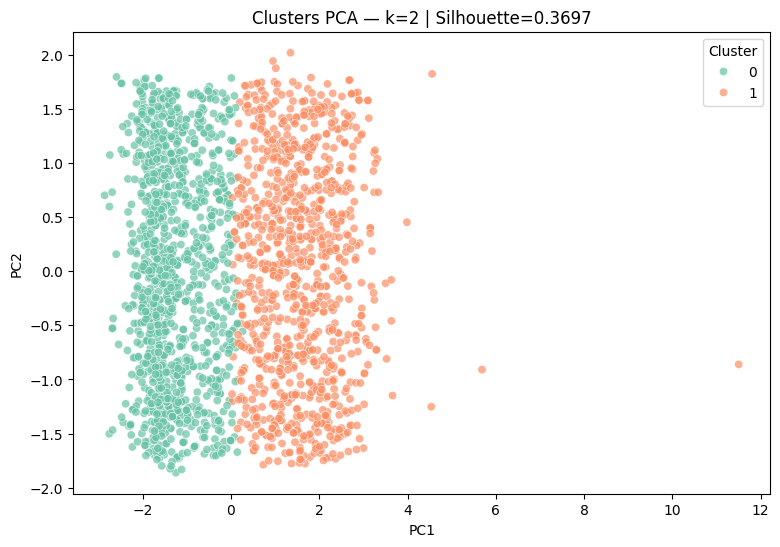

Variance expliquée par PC1+PC2 : 71.4%


In [16]:
# Visualisation PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_opt)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"].values

plt.figure(figsize=(9, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=pca_df,
                palette="Set2", alpha=0.7)
plt.title(f"Clusters PCA — k={best_k_final} | Silhouette={final_score:.4f}")
plt.show()

print(f"Variance expliquée par PC1+PC2 : {pca.explained_variance_ratio_.sum()*100:.1f}%")